In [90]:
import shap as shap
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import numpy as np

from custom_transformers import HostSinceTransformer, BathroomExtractor, UKHostBinaryEncoder, HostResponseOrdinalEncoder

In [49]:
# load JS visualization code to notebook
shap.initjs()

In [50]:
X_train = pd.read_csv("data/X_train.csv")
X_test = pd.read_csv("data/X_test.csv")
y_train = pd.read_csv("data/y_train.csv").squeeze()  # Convert to Series
y_test = pd.read_csv("data/y_test.csv").squeeze()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1465, 28), (629, 28), (1465,), (629,))

In [51]:
preprocessing_pipeline = joblib.load('data/preprocessed/preprocessing_pipeline.pkl')
lgbm = joblib.load('model/final_model.pkl')

In [52]:
X_train_enc = pd.DataFrame(
    data=preprocessing_pipeline.transform(X_train),
    index=X_train.index,
    columns=preprocessing_pipeline.get_feature_names_out()
)

X_test_enc = pd.DataFrame(
    data=preprocessing_pipeline.transform(X_test),
    index=X_test.index,
    columns=preprocessing_pipeline.get_feature_names_out()
)

X_train_enc.head()


,low_missing__host_listings_count,low_missing__latitude,low_missing__longitude,low_missing__accommodates,low_missing__bathrooms,low_missing__bedrooms,low_missing__beds,low_missing__minimum_nights,low_missing__maximum_nights,low_missing__minimum_minimum_nights,...,host_since__host_year,host_since__host_month,host_since__host_days_active,uk_host__is_uk_host,uk_host__outside_uk_host,bathrooms__bathrooms_extracted,response_time__host_response_time_encoded,cat_missing__host_is_superhost_Unknown,cat_missing__host_is_superhost_f,cat_missing__host_is_superhost_t
0,0.481188,-0.052669,1.347349,0.177316,-0.468736,-0.617498,-0.079328,-0.430621,-0.840356,-0.184198,...,2022.0,6.0,1134.0,0.0,1.0,1.0,3.0,0.0,1.0,0.0
1,-0.435693,0.559553,0.010630,-0.692930,-0.468736,-0.617498,-0.700797,-0.430621,-0.155536,-0.409825,...,2015.0,9.0,3628.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0
2,-0.453326,0.160356,-0.103259,-0.692930,-0.468736,-0.617498,-0.700797,2.398345,-0.155536,-0.184198,...,2015.0,1.0,3849.0,1.0,0.0,1.0,4.0,0.0,1.0,0.0
3,-0.453326,1.370774,-0.542827,-1.128054,-0.468736,-0.617498,-0.700797,-0.430621,-0.989772,-0.409825,...,2021.0,10.0,1395.0,0.0,1.0,1.0,2.0,0.0,0.0,1.0
4,-0.453326,-0.450536,0.262536,-0.692930,-0.468736,-0.617498,-0.700797,0.004605,-0.155536,0.041429,...,2014.0,4.0,4129.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0


In [53]:
# Use the already trained model loaded from joblib
model = lgbm  # lgbm is loaded and already trained

# Use the underlying LightGBM regressor for SHAP
regressor = model.named_steps['lgbmregressor']

explainer = shap.TreeExplainer(regressor)
train_shap_values = explainer(X_train_enc)
test_shap_values = explainer(X_test_enc)

plt.figure(figsize=(10, 8))
shap.summary_plot(
    train_shap_values, 
    X_train_enc, 
    plot_size=(10, 8),
    plot_type="bar",
    show=False,
    max_display=10,
)
plt.tick_params(axis='y', labelsize=6) 
plt.tight_layout()
plt.show()

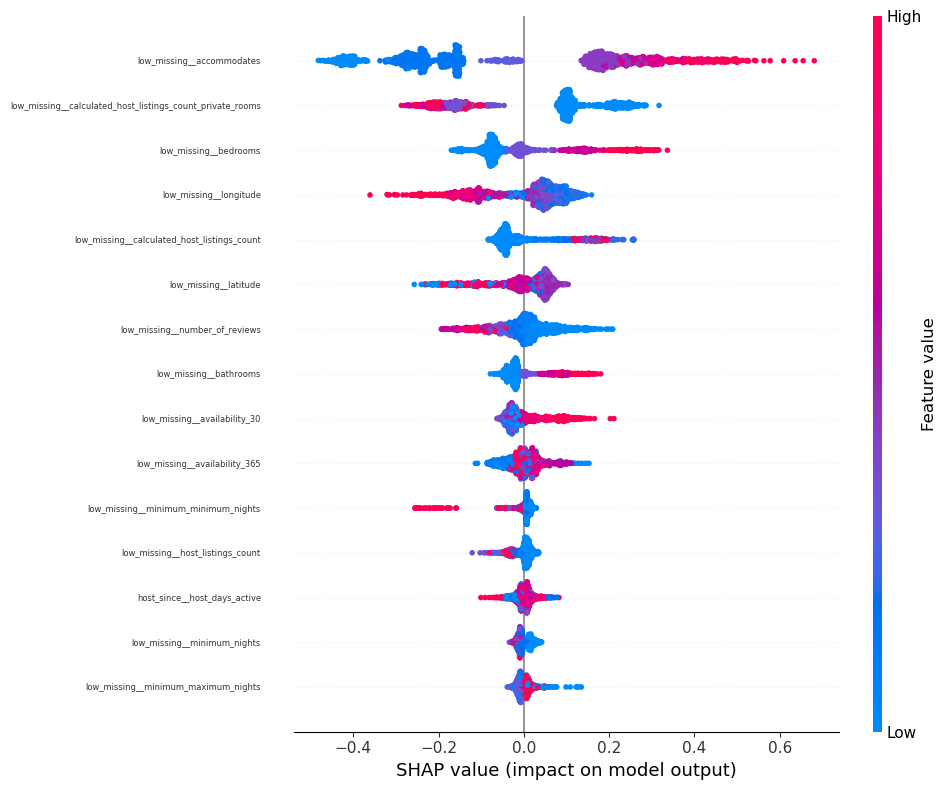

In [54]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    train_shap_values, 
    X_train_enc, 
    plot_size=(10, 8), 
    show=False,
    max_display=15,
)
plt.tick_params(axis='y', labelsize=6) 
plt.tight_layout()
plt.show()

### Top Contributing Features
- low_missing__accommodates:
    - This one is the most important feature.
    - High values (red) are associated with higher predictions — indicating that listings accommodating more guests are likely to fall into higher price bins.
    - Low values (blue) push predictions lower, aligning with expectations.
- low_missing__calculated_host_listings_count_private_rooms
    - Shows a strong negative impact when values are high.
    - Suggests that hosts with many private room listings tend to be associated with lower-price listings, possibly due to a more budget-focused strategy, which makes sense
- low_missing__bedrooms
    - Strongly contributes positively when the number of bedrooms is high (red).
    - Reinforces that larger listings tend to be more expensive, which is intuitive.
- low_missing__longitude
    - Mixed impact across values.
    - May reflect geographic location within a city (e.g., west vs east side). The distribution suggests the model is picking up non-linear, location-based pricing effects.
- low_missing__calculated_host_listings_count
    - Similar to private rooms, having more listings appears to lower the predicted price category, especially when the host is a high-volume operator.


### Geographic & Temporal Features
- low_missing__latitude and low_missing__longitude
    - Both have substantial impact, confirming that location is a major driver of price prediction, even within a single city.
- host_since__host_days_active
    - Higher values (older hosts) seem to slightly increase the prediction.
    - May suggest that experienced hosts are associated with more premium listings or pricing confidence.

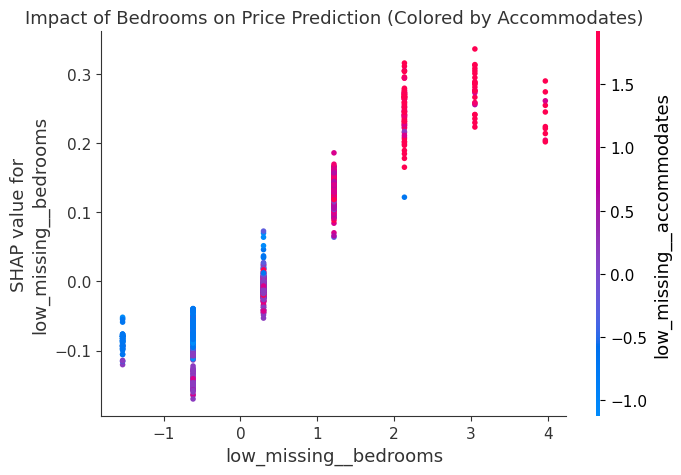

In [70]:
shap.dependence_plot(
    "low_missing__bedrooms",
    train_shap_values.values,
    X_train_enc,
    title="Impact of Bedrooms on Price Prediction (Colored by Accommodates)"
)

- X-axis (low_missing__bedrooms): The number of bedrooms in the listing (processed feature)
- Y-axis (SHAP value for low_missing__bedrooms): The impact on the model’s predicted price
- Positive SHAP value: increases predicted price
- Negative SHAP value: decreases predicted price
- Color (low_missing__accommodates): Number of guests accommodated (scaled)
- Blue = fewer guests, red = more guests

From this graph we can deduct that:
- More bedrooms generally increase price predictions
    - SHAP values move upward as bedrooms increases, showing a positive relationship.
- Influence grows with capacity
    - Red points (more accommodates) tend to have higher SHAP values at the same bedroom count, meaning the model predicts an even higher price when the property has both more bedrooms and accommodates more guests.
- Negative or near-zero SHAP for very low bedrooms
    - Properties with very few bedrooms (or missing/negative imputed values) slightly lower predicted prices.

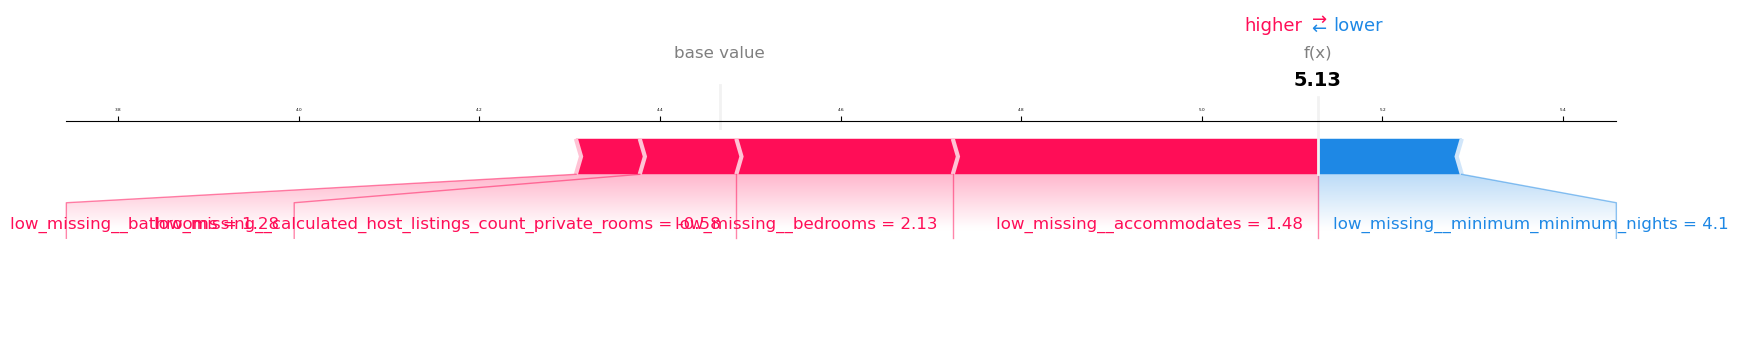

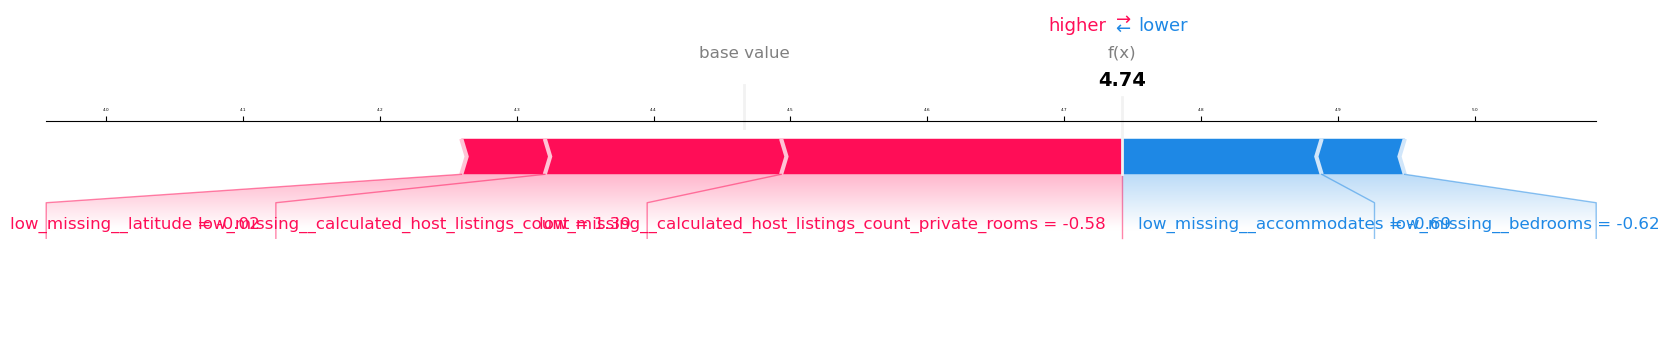

In [111]:
# Showo SHAP force plot form 5 random samples from the training set

np.random.seed(3)

sample_indices = np.random.choice(X_train_enc.index, size=2, replace=False)

k = 5  # show top 5 contributions

for idx in sample_indices:
    vals = train_shap_values.values[idx]
    base = train_shap_values.base_values[idx]

    # Round feature values
    feats = np.round(X_train_enc.iloc[idx].values, 2)
    names = X_train_enc.columns.to_numpy()

    keep = np.argsort(np.abs(vals))[::-1][:k]   # top-k by |SHAP|

    shap.force_plot(
        base,
        vals[keep],
        feats[keep],
        feature_names=names[keep],
        matplotlib=True,
    )

For SHAP force plots exhibit the following characteristics:
- Base value: The average model output across the training set. This is where the prediction starts.
- f(x) value: The final model output for this specific listing after adding all SHAP contributions.
- Red features: Push the prediction higher than the base value.
- Blue features: Push the prediction lower than the base value.
- Feature labels: Shown as feature_name = feature_value, with your processed feature names like low_missing__bedrooms meaning “bedrooms (after missing value handling)”.

First plot:

- Base value: ~4.76
- Final prediction (f(x)): 5.13. This listing is predicted to have a higher price than average.
- Positive contributions (red — push price up)
    - low_missing__bathrooms = 2.26. More bathrooms than typical listing increases predicted price.
    - low_missing__bedrooms = 2.13. Higher bedroom count significantly boosts price prediction.
    - low_missing__accommodates = 1.48. Can host more guests, pushing price upward.
- Negative contributions (blue — push price down)
    - low_missing__minimum_minimum_nights = 4.1. The minimum possible stay is longer than average, which slightly reduces predicted price.
    - low_missing__calculated_host_listings_count_private_rooms = -0.58. The host has multiple private-room listings, which the model associates with lower per-listing prices.

All in all, high bedroom/bathroom count and guest capacity outweigh the negative effect of a high minimum stay requirement.



On the second plot:
- Base value: ~4.76
- Final prediction (f(x)): 4.74. Very close to average predicted price.
- Positive contributions (red — push price up)
    - low_missing__latitude = -0.02. Latitude location slightly increases predicted price (small effect).
    - low_missing__calculated_host_listings_count = 1.53. The number of total host listings slightly increases predicted price.
    - low_missing__calculated_host_listings_count_private_rooms = -0.58. Here, the effect is small because of mixed pushes.
- Negative contributions (blue — push price down)
    - low_missing__accommodates = 1.05. Surprisingly here, accommodates is pulling prediction down — possibly because capacity is mismatched with other listing attributes.
    - low_missing__bedrooms = -0.62. Fewer bedrooms reduces price prediction.

All in all. Location and some host-related metrics push the price slightly up, but fewer bedrooms and guest capacity pull it back down, resulting in an almost average price prediction.